# Table of Contents
- Intro to Computer Vision and CNN `(Check Slide and Class Video)`
- CNN Fashion MNIST Classification


# 👔 Fashion Product Classification using Artificial Neural Network

![](https://www.researchgate.net/profile/Saeed-Reza-Kheradpisheh/publication/342801790/figure/fig2/AS:911232181735425@1594266090934/Sample-images-from-Fashion-MNIST-dataset.png)

In [20]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy jupyter notebook ipykernel plotly tensorflow keras opencv-python pillow tqdm pydot

Note: you may need to restart the kernel to use updated packages.


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

## 📥 2. Load Fashion MNIST Dataset

In [22]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train.shape)  # (60000, 28, 28)
print(y_train.shape)

print(x_test.shape)  # (10000, 28, 28)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [23]:
# Label mapper

idx_to_label = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

## 🎨 3. Visualization of Sample Data

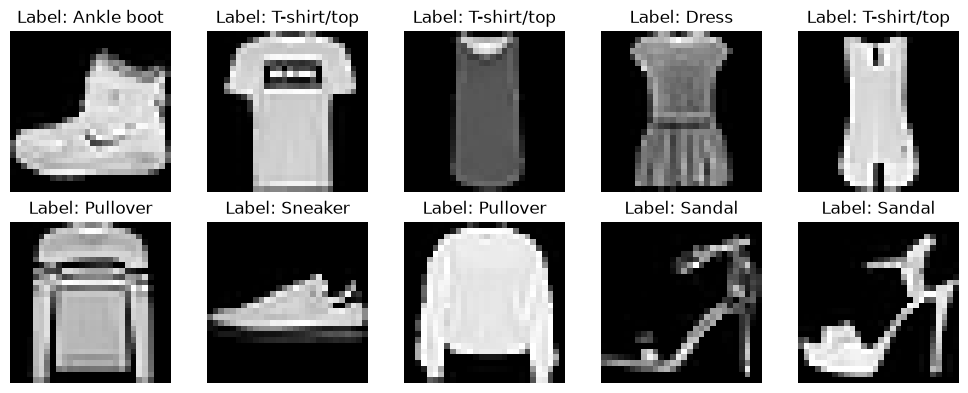

In [24]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {idx_to_label[y_train[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing (Normalization)

![](https://lh3.googleusercontent.com/proxy/wNLhUqpOpBGPmfUIopgsshTtyJHh8VnAl5Ef4Koz9vXhLQ5osTQBwi5dTV-SbeL7NV6mRN_bOM8OO2bFL8Np3AQQTjdKm3Qb5MNhmB3Ts0E954BJJl-cjHp5f1c6znVIahNpuA)


In [25]:
print(f"Max pixel value before Normalization: {x_train.max()}")
print(f"Min pixel value before Normalization: {x_train.min()}")

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"Max pixel value after Normalization: {x_train.max()}")
print(f"Min pixel value after Normalization: {x_train.min()}")

Max pixel value before Normalization: 255
Min pixel value before Normalization: 0
Max pixel value after Normalization: 1.0
Min pixel value after Normalization: 0.0


In [26]:
print(f"Train data shape before reshaping: {x_train.shape}")
print(f"Test data shape before reshaping: {x_test.shape}")

# CNN expects:
# (batch, height, width, channel)

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(f"Train data shape after reshaping: {x_train.shape}")
print(f"Test data shape after reshaping: {x_test.shape}")

Train data shape before reshaping: (60000, 28, 28)
Test data shape before reshaping: (10000, 28, 28)
Train data shape after reshaping: (60000, 28, 28, 1)
Test data shape after reshaping: (10000, 28, 28, 1)


## 🏗️ 5. Build CNN Model

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRnBcx-4BZBEEc2MVTHnmI4w-I_Sn5eQSl0sHidUP3llFy7dDL6BCgrmg8&s=10)

In [27]:
model = models.Sequential([

    layers.Input(shape=(28,28,1)),

    # Feature extraction
    layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Converting 2d/3d data into 1d
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation="relu"),

    # Classification -> 10 category
    layers.Dense(units=10, activation="softmax")

])

In [29]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='neural_network_plot.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='LR', # 'TB' for top-to-bottom layout; 'LR' for left-to-right layout
    show_layer_activations=True
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


# ⚙️ 6. Compile Model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# 🚀 7. Train Model

In [31]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8152 - loss: 0.5169 - val_accuracy: 0.8632 - val_loss: 0.3751
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8772 - loss: 0.3394 - val_accuracy: 0.8891 - val_loss: 0.3103
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8945 - loss: 0.2916 - val_accuracy: 0.8957 - val_loss: 0.2906
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9061 - loss: 0.2582 - val_accuracy: 0.9050 - val_loss: 0.2649
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9135 - loss: 0.2339 - val_accuracy: 0.9047 - val_loss: 0.2587
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9223 - loss: 0.2120 - val_accuracy: 0.9035 - val_loss: 0.2790
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9297 - loss: 0.1919 - val_accuracy: 0.9094 - val_loss: 0.2482
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9358 - loss: 0.1726 - va

# 📈 8. Training Visualization

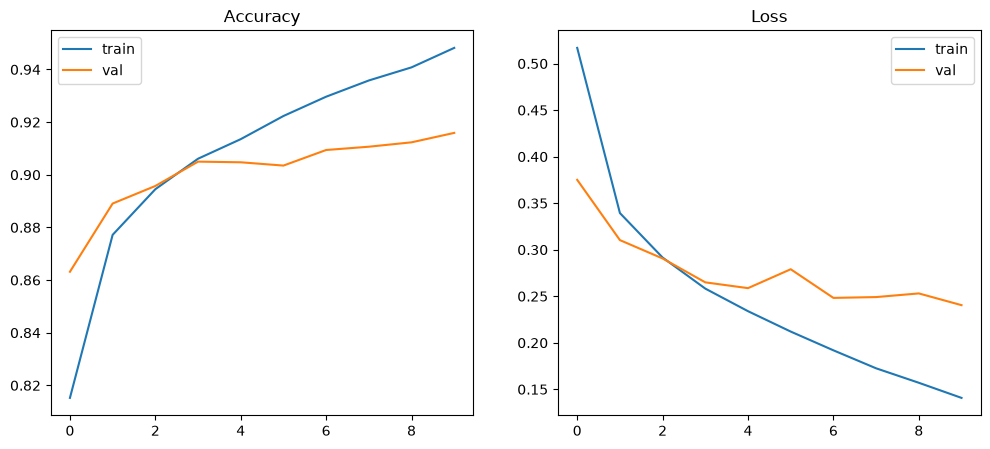

In [32]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

# 🔮 9. Predictions Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


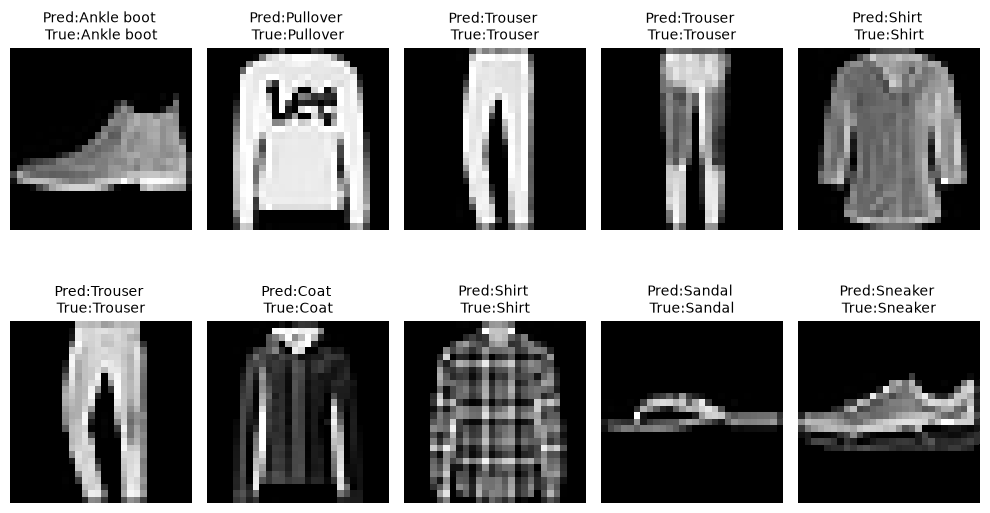

In [33]:
predictions = model.predict(x_test)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"Pred:{idx_to_label[pred_label]} \nTrue:{idx_to_label[true_label]}",
              fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# 📊 10. Evaluate Model

In [34]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9103 - loss: 0.2537
Test Accuracy: 0.9103000164031982


In [35]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1000
           1       0.99      0.98      0.98      1000
           2       0.88      0.84      0.86      1000
           3       0.90      0.91      0.91      1000
           4       0.83      0.90      0.86      1000
           5       0.99      0.97      0.98      1000
           6       0.77      0.71      0.74      1000
           7       0.94      0.98      0.96      1000
           8       0.97      0.98      0.98      1000
           9       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



# 11. Error Analysis

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


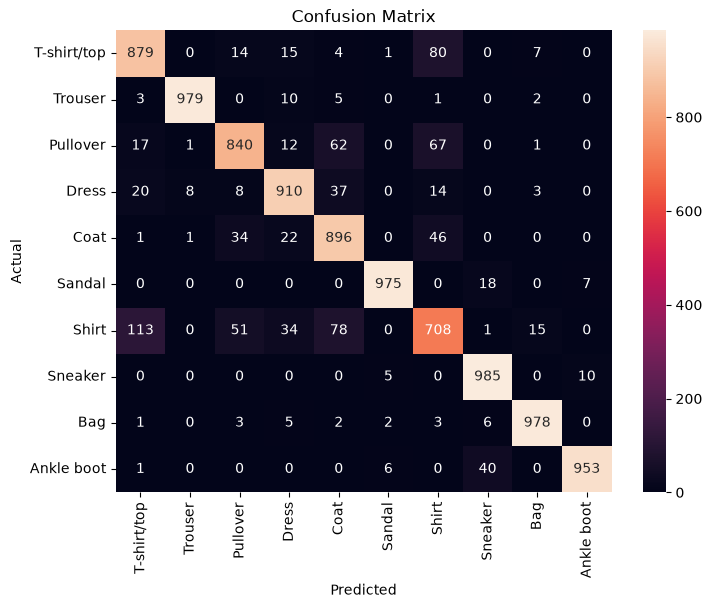

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=idx_to_label.values(),
    yticklabels=idx_to_label.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Total errors: 897


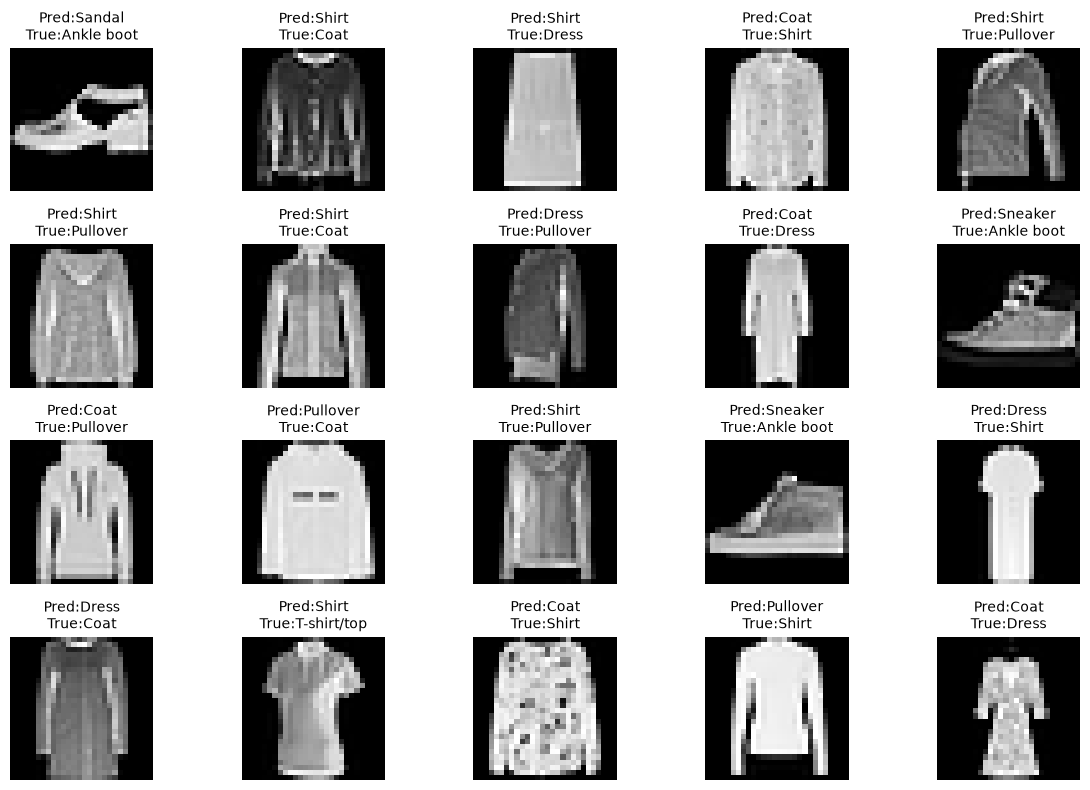

In [37]:
# Get predictions
predictions = model.predict(x_test)

# Convert probabilities to labels
pred_labels = np.argmax(predictions, axis=1)


# Find wrong predictions
errors = np.where(pred_labels != y_test)[0]


print("Total errors:", len(errors))


# Visualize wrong predictions
plt.figure(figsize=(12, 8))

for i, idx in enumerate(errors[:20]):   # show first 20 mistakes

    plt.subplot(4, 5, i+1)

    plt.imshow(
        x_test[idx].reshape(28,28),
        cmap='gray'
    )

    pred_label = pred_labels[idx]
    true_label = y_test[idx]

    plt.title(
        f"Pred:{idx_to_label[pred_label]}\nTrue:{idx_to_label[true_label]}",
        fontsize=10
    )

    plt.axis('off')


plt.tight_layout()
plt.show()

# 12. Saving the Model

In [38]:
model_name = "cnn_fashion_mnist_with_batchnorm.h5"

model.save(model_name)

In [39]:
loaded_model = tf.keras.models.load_model(model_name)
print("Model loaded successfully!")

Model loaded successfully!
